
<div style="text-align: center; line-height: 0; padding-top: 9px;">
  <img src="https://databricks.com/wp-content/uploads/2018/03/db-academy-rgb-1200px.png" alt="Databricks Learning">
</div>


# LAB - Model Training and Tracking with MLflow
In this lab, you will train a machine learning model on cleaned data and track it using MLflow.

**Lab Outline:**

_This lab contains the following tasks:_
1. Load and split the cleaned dataset.
2. Train a RandomForestClassifier model.
3. Evaluate the model's performance.
4. Save the best model for deployment.

## Requirements
Please review the following requirements before starting the lesson:
- To run this notebook, you need to use one of the following Databricks runtime(s): `16.3.x-cpu-ml-scala2.12`

## Classroom Setup
Before starting the lab, run the provided classroom setup script. This script will define configuration variables necessary for the demo. Execute the following cell:


In [0]:
%run ../../Includes/Classroom-Setup-1.1a

  Using cached databricks_sdk-0.36.0-py3-none-any.whl.metadata (38 kB)
Using cached databricks_sdk-0.36.0-py3-none-any.whl (569 kB)
  Attempting uninstall: databricks-sdk
    Found existing installation: databricks-sdk 0.30.0
    Not uninstalling databricks-sdk at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-cb42777d-acd9-4723-8f41-dc313905d60a
    Can't uninstall 'databricks-sdk'. No files were found to uninstall.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


**Other Conventions**

Throughout this lab, we'll refer to the object `DA`. This object, provided by Databricks Academy, contains variables such as your username, catalog name, schema name, working directory, and dataset locations. Run the code block below to view these details:

In [0]:
print(f"Username:          {DA.username}")
print(f"Catalog Name:      {DA.catalog_name}")
print(f"Schema Name:       {DA.schema_name}")
print(f"Working Directory: {DA.paths.working_dir}")
print(f"User DB Location:  {DA.paths.datasets}")

Username:          labuser11256191_1759794214@vocareum.com
Catalog Name:      dbacademy
Schema Name:       labuser11256191_1759794214
Working Directory: /Volumes/dbacademy/ops/labuser11256191_1759794214@vocareum_com
User DB Location:  NestedNamespace (banking='/Volumes/dbacademy_banking/v01', cdc_diabetes='/Volumes/dbacademy_cdc_diabetes/v01', monitoring='/Volumes/dbacademy_monitoring/v01', telco='/Volumes/dbacademy_telco/v01')


## Task 1: Data Preparation
This task involves loading the cleaned dataset, handling missing values, and splitting the data for training and testing.

### Task 1.1 Load the Cleaned Data
Load the cleaned data from the Delta table.

In [0]:
import pandas as pd
# Read dataset from the feature store table
table_name = f"{DA.catalog_name}.{DA.schema_name}.telco_cleaned_table"
feature_data_pd = spark.table(table_name).toPandas()

# Drop the 'customerID' column
feature_data_pd = feature_data_pd.drop(columns=['customerID'])

# Add unique_id column
feature_data_pd['unique_id'] = range(len(feature_data_pd))

# Convert all columns in the DataFrame to the 'double' data type
feature_data_pd = feature_data_pd.astype("double")

# Display the DataFrame and print the columns
display(feature_data_pd)

gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,num_optional_services,unique_id
null,0.0,1.0,0.0,1.0,null,null,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,29.85,29.85,0.0,0.0,0.0
1.0,0.0,0.0,0.0,34.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,2.0,56.95,1889.5,0.0,0.0,1.0
1.0,0.0,0.0,0.0,2.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,53.85,108.15,1.0,0.0,2.0
1.0,0.0,0.0,0.0,45.0,0.0,null,2.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,3.0,42.3,1840.75,0.0,0.0,3.0
0.0,0.0,0.0,0.0,0.0,null,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,4.0,70.7,151.65,1.0,0.0,4.0
0.0,0.0,0.0,0.0,8.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,4.0,99.65,820.5,1.0,0.0,5.0
1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,89.1,1949.4,0.0,0.0,6.0
0.0,0.0,0.0,null,10.0,0.0,null,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.0,29.75,301.9,0.0,0.0,7.0
null,0.0,1.0,0.0,28.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,104.8,3046.05,1.0,0.0,8.0
1.0,0.0,0.0,1.0,62.0,1.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0,56.15,3487.95,0.0,0.0,9.0


### Task 1.2 Handle Missing Values
Use an imputer to fill in the missing values.

In [0]:
from sklearn.impute import SimpleImputer

# Handle missing values
imputer = SimpleImputer(strategy='mean')
imputed_data = imputer.fit_transform(feature_data_pd)
feature_data_pd = pd.DataFrame(imputed_data, columns=feature_data_pd.columns)

### Task 1.3 Split the Data
Split the data into training and testing sets.

In [0]:
from sklearn.model_selection import train_test_split

print(f"We have {feature_data_pd.shape[0]} records in our source dataset")

# split target variable into its own dataset
target_col = "Churn"
X_all = feature_data_pd.drop(labels=target_col, axis=1)
y_all = feature_data_pd[target_col]

# test / train split
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, train_size=0.8, random_state=42)
print(f"We have {X_train.shape[0]} records in our training dataset")
print(f"We have {X_test.shape[0]} records in our test dataset")

We have 7043 records in our source dataset
We have 5634 records in our training dataset
We have 1409 records in our test dataset


## Task 2: Fit and Log the Model
Train a RandomForestClassifier model, evaluate its performance, and log the model along with its parameters and metrics using MLflow.

In [0]:
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
from mlflow.tracking import MlflowClient
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configure MLflow client to access models in Unity Catalog
mlflow.set_registry_uri('databricks-uc')

# Fetch Model information
client = mlflow.tracking.MlflowClient()
model_name = f"{DA.catalog_name}.{DA.schema_name}.churn-prediction" 

# Helper function to get the latest model version
def get_latest_model_version(model_name):
    """Helper function to get latest model version"""
    model_version_infos = client.search_model_versions(f"name = '{model_name}'")
    return max([model_version_info.version for model_version_info in model_version_infos])

# Set the path for MLflow experiment
mlflow.set_experiment(f"/Users/{DA.username}/Lab-1.2b-Model-traning-with-MLflow")

# Turn off autologging
mlflow.sklearn.autolog(disable=True)

# Define model parameters
rf_params = {
    "n_estimators": 100,
    "random_state": 42
}

# Start an MLflow run
with mlflow.start_run(run_name="Model Training Lab") as run:
    # Log the dataset as artifacts
    feature_data_pd.to_csv("/tmp/feature_data.csv", index=False)
    X_train.to_csv("/tmp/X_train.csv", index=False)
    X_test.to_csv("/tmp/X_test.csv", index=False)
    
    mlflow.log_artifact("/tmp/feature_data.csv", artifact_path="feature_data")
    mlflow.log_artifact("/tmp/X_train.csv", artifact_path="training_data")
    mlflow.log_artifact("/tmp/X_test.csv", artifact_path="test_data")

    # Log our parameters
    mlflow.log_params(rf_params)

    # Fit the model
    rf = RandomForestClassifier(**rf_params)
    rf_mdl = rf.fit(X_train, y_train)

    # Define model signature
    signature = infer_signature(X_train, y_train)

    # Log the model
    mlflow.sklearn.log_model(
        sk_model=rf_mdl,
        artifact_path="model-artifacts",
        signature=signature,
        registered_model_name=model_name  # Provide a valid name for the registered model
    )

    # Evaluate on the training set
    y_train_pred = rf_mdl.predict(X_train)
    mlflow.log_metric("train_accuracy", accuracy_score(y_train, y_train_pred))
    mlflow.log_metric("train_precision", precision_score(y_train, y_train_pred))
    mlflow.log_metric("train_recall", recall_score(y_train, y_train_pred))
    mlflow.log_metric("train_f1", f1_score(y_train, y_train_pred))

    # Evaluate on the test set
    y_test_pred = rf_mdl.predict(X_test)
    mlflow.log_metric("test_accuracy", accuracy_score(y_test, y_test_pred))
    mlflow.log_metric("test_precision", precision_score(y_test, y_test_pred))
    mlflow.log_metric("test_recall", recall_score(y_test, y_test_pred))
    mlflow.log_metric("test_f1", f1_score(y_test, y_test_pred))

    # Set model alias
    latest_model_version = get_latest_model_version(model_name)
    client.set_registered_model_alias(model_name, "Baseline", latest_model_version)

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Registered model 'dbacademy.labuser11256191_1759794214.churn-prediction' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Created version '2' of model 'dbacademy.labuser11256191_1759794214.churn-prediction'.
2025/10/07 00:41:51 INFO mlflow.tracking._tracking_service.client: 🏃 View run Model Training Lab at: dbc-bcd7adfe-8f71.cloud.databricks.com/ml/experiments/1142554600512089/runs/dac002bac0b44c3787033d286cb24fc5.
2025/10/07 00:41:51 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: dbc-bcd7adfe-8f71.cloud.databricks.com/ml/experiments/1142554600512089.


## Task 3: Visualize Model Performance
Generate and log confusion matrix and feature importance plots.

### Task 3.1 Confusion Matrix
Generate and log a confusion matrix to evaluate the model's performance.

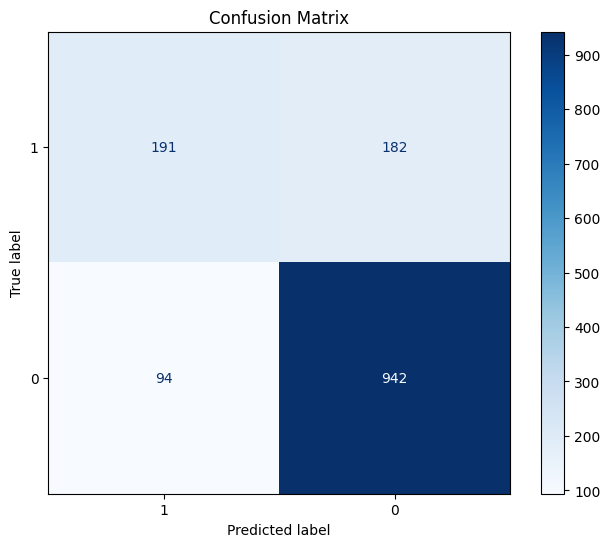

In [0]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Computing the confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

# Creating a figure object and axes for the confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

# Plotting the confusion matrix using the created axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 0])
disp.plot(cmap=plt.cm.Blues, ax=ax)

# Setting the title of the plot
ax.set_title('Confusion Matrix')

# Now 'fig' can be used with MLFlow's log_figure function
client.log_figure(run.info.run_id, figure=fig, artifact_file="confusion_matrix.png")

# Showing the plot here for demonstration
plt.show()

### Task 3.2 Feature Importance Plots
Generate and log a feature importance plot to understand the significance of each feature.

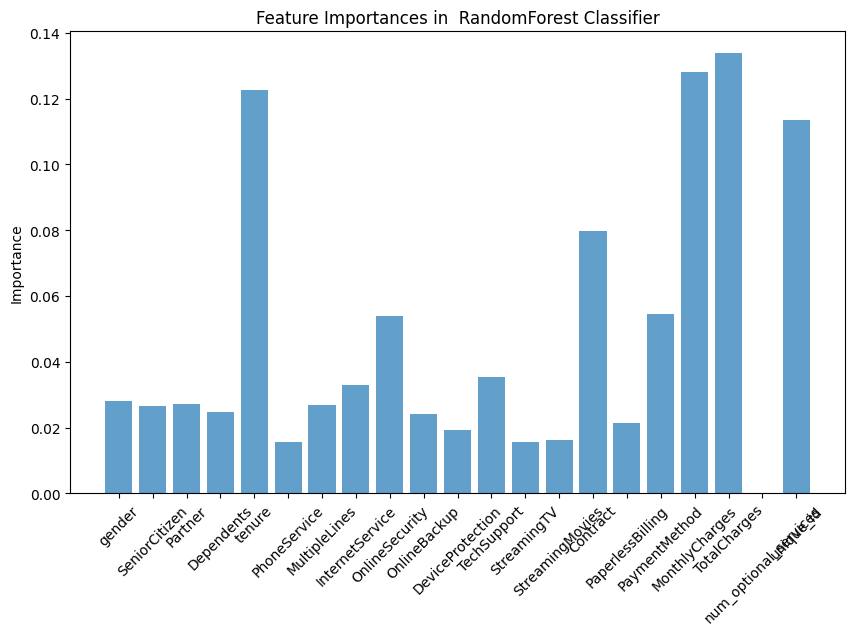

In [0]:
import numpy as np

# Retrieving feature importances
feature_importances = rf_mdl.feature_importances_
feature_names = X_train.columns.to_list()

# Plotting the feature importances
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(feature_names))
ax.bar(y_pos, feature_importances, align='center', alpha=0.7)
ax.set_xticks(y_pos)
ax.set_xticklabels(feature_names, rotation=45)
ax.set_ylabel('Importance')
ax.set_title('Feature Importances in  RandomForest Classifier')

# log to mlflow
client.log_figure(run.info.run_id, figure=fig, artifact_file="feature_importances.png")

# display here
plt.show()

## Task 4: Search for the Best Run

### Task 4.1 Find the best run in the AutoML experiment
Execute AutoML to find the best model.

In [0]:
from databricks import automl
from datetime import datetime
# Start an AutoML classification run
automl_run = automl.classify(
    dataset = spark.table("telco_cleaned_table"),
    target_col = "Churn",
    timeout_minutes = 5
    )

(2025-10-07 00:41:55) WARNING: Hyperopt is deprecated for Databricks runtime for machine learning and will not be pre-installed in the next major version.
2025/10/07 00:41:57 INFO databricks.automl.client.manager: AutoML will optimize for F1 score metric, which is tracked as val_f1_score in the MLflow experiment.
2025/10/07 00:41:57 INFO databricks.automl.client.manager: MLflow Experiment ID: 1142554600512113
2025/10/07 00:41:57 INFO databricks.automl.client.manager: MLflow Experiment: https://dbc-bcd7adfe-8f71.cloud.databricks.com/?o=2793521850962087#mlflow/experiments/1142554600512113
2025/10/07 00:43:09 INFO databricks.automl.client.manager: Data exploration notebook: https://dbc-bcd7adfe-8f71.cloud.databricks.com/?o=2793521850962087#notebook/1142554600512118
2025/10/07 00:47:32 INFO databricks.automl.client.manager: AutoML experiment completed successfully.


,Train,Validation,Test
f1_score,0.584,0.555,0.606
recall_score,0.519,0.501,0.530
roc_auc,0.851,0.833,0.855
false_negatives,519.000,191.000,191.000
false_positives,281.000,117.000,88.000
example_count,4204.000,1453.000,1386.000
precision_score,0.666,0.621,0.710
true_positives,561.000,192.000,215.000
precision_recall_auc,0.665,0.634,0.717
true_negatives,2843.000,953.000,892.000


### Task 4.2 Get Experiment ID and Search for Runs by Experiment
Get the experiment ID and search for the runs by experiment.

In [0]:
import mlflow

# Get the experiment path by experiment ID
exp_path = mlflow.get_experiment(automl_run.experiment.experiment_id).name
# Find the most recent experiment in the AutoML folder
filter_string=f'name LIKE "{exp_path}"'
automl_experiment_id = mlflow.search_experiments(
  filter_string=filter_string,
  max_results=1,
  order_by=["last_update_time DESC"])[0].experiment_id

from mlflow.entities import ViewType

# Find the best run ...
automl_runs_pd = mlflow.search_runs(
  experiment_ids=[automl_experiment_id],
  filter_string=f"attributes.status = 'FINISHED'",
  run_view_type=ViewType.ACTIVE_ONLY,
  order_by=["metrics.val_f1_score DESC"]
)
# Display the best run
automl_runs_pd

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.val_recall_score,metrics.val_true_negatives,metrics.val_log_loss,metrics.training_accuracy_score,metrics.training_precision_score,metrics.test_recall_score,metrics.training_recall_score,metrics.test_true_negatives,metrics.val_precision_recall_auc,metrics.test_f1_score,metrics.training_f1_score,metrics.test_false_positives,metrics.val_false_negatives,metrics.val_false_positives,metrics.test_example_count,metrics.test_precision_score,metrics.training_roc_auc,metrics.val_score,metrics.test_true_positives,metrics.val_roc_auc,metrics.training_true_negatives,metrics.test_score,metrics.val_true_positives,metrics.test_precision_recall_auc,metrics.training_true_positives,metrics.test_roc_auc,metrics.val_example_count,metrics.training_example_count,metrics.val_f1_score,metrics.test_false_negatives,metrics.test_accuracy_score,metrics.training_false_positives,metrics.training_score,metrics.test_log_loss,...,params.classifier__classifier__random_state,params.classifier__classifier__colsample_bylevel,params.classifier__n_estimators,params.classifier__oob_score,params.classifier__max_samples,params.classifier__min_samples_split,params.classifier__max_features,params.classifier__criterion,params.classifier__max_leaf_nodes,params.classifier__min_samples_leaf,params.classifier__monotonic_cst,params.classifier__min_weight_fraction_leaf,params.classifier__min_impurity_decrease,params.classifier__bootstrap,params.classifier__ccp_alpha,params.classifier__max_depth,params.classifier__splitter,tags.estimator_class,tags.mlflow.databricks.notebookID,tags.mlflow.datasets,tags.mlflow.databricks.notebookPath,tags.mlflow.user,tags.mlflow.source.name,tags.mlflow.runName,tags.estimator_name,tags.mlflow.runColor,tags.model_type,tags.mlflow.source.type,tags.mlflow.log-model.history,tags.mlflow.databricks.cluster.id,tags.mlflow.databricks.jobType,tags.mlflow.databricks.cluster.info,tags.mlflow.databricks.jobID,tags.mlflow.databricks.workspaceID,tags.mlflow.databricks.notebook.commandID,tags.mlflow.databricks.webappURL,tags.mlflow.databricks.workspaceURL,tags.sparkDatasourceInfo,tags.mlflow.databricks.jobRunID,tags.mlflow.databricks.cluster.libraries
0,32b2524591284cb8a4ad78e00b9156e1,1142554600512113,FINISHED,dbfs:/databricks/mlflow-tracking/1142554600512...,2025-10-07 00:45:25.729000+00:00,2025-10-07 00:47:06.021000+00:00,0.501305,953.0,0.426851,0.809705,0.666271,0.529557,0.519444,892.0,0.634448,0.606488,0.583767,88.0,191.0,117.0,1386.0,0.709571,0.851356,0.788025,215.0,0.833123,2843.0,0.798701,192.0,0.716935,561.0,0.855223,1453.0,4204.0,0.554913,191.0,0.798701,281.0,0.809705,0.421985,...,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sklearn.pipeline.Pipeline,1142554600512119,"[{""name"":""d2bede6a17de9a2b50a0319a7a6243df"",""h...",/Users/labuser11256191_1759794214@vocareum.com...,labuser11256191_1759794214@vocareum.com,Notebook: LogisticRegression(C=0.2076492237116...,magnificent-worm-80,Pipeline,#5bc5db,logistic_regression_classifier,NOTEBOOK,"[{""artifact_path"":""model"",""flavors"":{""python_f...",None,None,None,None,None,None,None,None,None,None,None
1,8926d89948d24ea38b47753f05edbbd1,1142554600512113,FINISHED,dbfs:/databricks/mlflow-tracking/1142554600512...,2025-10-07 00:43:28.823000+00:00,2025-10-07 00:44:58.843000+00:00,0.493473,958.0,0.431893,0.818982,0.689655,0.512315,0.537037,890.0,0.621934,0.590909,0.603852,90.0,194.0,112.0,1386.0,0.697987,0.863799,0.789401,208.0,0.829883,2863.0,0.792208,189.0,0.702519,580.0,0.851083,1453.0,4204.0,0.552632,198.0,0.792208,261.0,0.818982,0.428407,...,382077702,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,sklearn.pipeline.Pipeline,None,"[{""name"":""d2bede6a17de9a2b50a0319a7a6243df"",""h...",None,labuser11256191_1759794214@vocareum.com,None,clumsy-hawk-709,Pipeline,#e57439,xgboost_classifier,None,"[{""artifact_path"":""model"",""flavors"":{""python_f...",None,None,None,None,N

## Task 5: Save the Best Model
Save the model if it meets the accuracy threshold.

### Task 5.1 Register the Best Model
Register the best model from the AutoML experiment.

In [0]:
from mlflow.tracking import MlflowClient
from mlflow.models.signature import infer_signature

# Get the best run ID from AutoML
best_run_id = automl_runs_pd.at[0, 'run_id']
model_uri = f"runs:/{best_run_id}/model"
model_name = "best_automl_model"

### Task 5.2 Save and Log the Best Model
Save and log the best model to the MLflow model registry.

In [0]:
# Register the model in MLflow
model_details = mlflow.register_model(model_uri, model_name)

# Assuming model_details is a ModelVersion object
best_model_name = f"{DA.catalog_name}.{DA.schema_name}.best_automl_model" 

# Helper function to get the latest model version
def get_latest_model_version(best_model_name):
    """Helper function to get latest model version"""
    best_model_version_infos = client.search_model_versions(f"name = '{best_model_name}'")
    return max([model_version_info.version for model_version_info in best_model_version_infos])

# Set the path for MLflow experiment
mlflow.set_experiment(f"/Users/{DA.username}/Lab-1.2b-Best_Model-traning-with-MLflow")

# Turn off autologging
mlflow.sklearn.autolog(disable=True)

# Start an MLflow run
with mlflow.start_run(run_name="Best Model Training Lab") as run:
    # Define model signature
    signature = infer_signature(X_train, y_train)

    # Log the model
    mlflow.sklearn.log_model(
        sk_model=rf_mdl,
        artifact_path="model-artifacts",
        signature=signature,
        registered_model_name=best_model_name  # Provide a valid name for the registered model
    )

    # Set model alias
    latest_best_model_version = get_latest_model_version(best_model_name)
    client.set_registered_model_alias(best_model_name, "Baseline", latest_best_model_version)

Registered model 'best_automl_model' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/11 [00:00<?, ?it/s]

Created version '3' of model 'dbacademy.labuser11256191_1759794214.best_automl_model'.


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Registered model 'dbacademy.labuser11256191_1759794214.best_automl_model' already exists. Creating a new version of this model...


Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

Created version '4' of model 'dbacademy.labuser11256191_1759794214.best_automl_model'.


# Conclusion
In this lab, you learned how to train a machine learning model on cleaned data and track it using MLflow. You also evaluated the model's performance and saved the best model for deployment.


&copy; 2025 Databricks, Inc. All rights reserved. Apache, Apache Spark, Spark, the Spark Logo, Apache Iceberg, Iceberg, and the Apache Iceberg logo are trademarks of the <a href="https://www.apache.org/" target="blank">Apache Software Foundation</a>.<br/>
<br/><a href="https://databricks.com/privacy-policy" target="blank">Privacy Policy</a> | 
<a href="https://databricks.com/terms-of-use" target="blank">Terms of Use</a> | 
<a href="https://help.databricks.com/" target="blank">Support</a>